# 06 · Classification

[← Course home](../README.md)

Four classic classifiers, four different ideas of what "learning a boundary" means:

| Model | Idea |
|---|---|
| Logistic regression | model $P(y=1\mid\mathbf x)$ with a linear score squashed by a sigmoid |
| k-nearest neighbours | "you are the company you keep" — vote among the closest training points |
| Naive Bayes | model how each class *generates* features, then apply Bayes' rule |
| Support vector machine | find the separating boundary with the widest margin (and bend it with kernels) |

**What you will learn**

- Derive the logistic-regression loss and gradient, implement it **from scratch** with L2 regularisation,
  and match scikit-learn; extend to **softmax** for multiclass
- Implement **k-NN** from scratch, see how $k$ shapes the boundary, why **scaling** matters, and meet the
  **curse of dimensionality**
- Implement **Gaussian Naive Bayes** from scratch (priors, means, variances, log-likelihoods)
- Understand **maximum-margin** SVMs, the **hinge loss**, the $C$ trade-off and the **kernel trick**
  ($\gamma$ in the RBF kernel)
- Compare all classifiers visually and with a proper cross-validated benchmark

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.special import expit, logsumexp
from sklearn.datasets import (load_breast_cancer, load_wine, make_blobs, make_circles, make_classification,
                              make_moons)
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mlaz import PALETTE, load_penguins, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 4)

# Colour-blind-safe blue ↔ orange maps for binary problems, and a 3-class map for penguins
CMAP_BG = LinearSegmentedColormap.from_list("bo", [PALETTE[0], "#FFFFFF", PALETTE[1]])
CMAP_PTS = ListedColormap([PALETTE[0], PALETTE[1]])
CMAP_3 = ListedColormap([PALETTE[0], PALETTE[1], PALETTE[2]])


def plot_boundary(ax, model, X, y, response="auto", title=None, levels=None):
    """Shade the model's scores over the plane and overlay the data points."""
    DecisionBoundaryDisplay.from_estimator(model, X, response_method=response, cmap=CMAP_BG, alpha=0.8,
                                           ax=ax, grid_resolution=200, eps=0.5, plot_method="contourf",
                                           levels=levels)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP_PTS, edgecolor="k", linewidth=0.5, s=22)
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

## 1 · Logistic regression from scratch

### Model

A linear score $z = \mathbf w^\top\mathbf x + b$ is squashed into a probability by the **sigmoid**

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad P(y=1\mid\mathbf x) = p = \sigma(\mathbf w^\top\mathbf x + b).$$

Equivalently, the **log-odds** are linear: $\log\frac{p}{1-p} = \mathbf w^\top\mathbf x + b$. The decision
boundary $p = 0.5$ is the hyperplane $\mathbf w^\top\mathbf x + b = 0$.

### Loss: binary cross-entropy (negative log-likelihood)

Each label is a Bernoulli draw, $P(y_i\mid\mathbf x_i) = p_i^{y_i}(1-p_i)^{1-y_i}$. Maximising the likelihood
of the data is the same as minimising the mean negative log-likelihood, plus an L2 penalty:

$$ J(\mathbf w, b) = -\frac1n\sum_{i=1}^n\Big[y_i\log p_i + (1-y_i)\log(1-p_i)\Big]
   + \frac{\lambda}{2}\lVert\mathbf w\rVert^2 .$$

### Gradient

Using $\sigma'(z)=\sigma(z)(1-\sigma(z))$, the derivative of one example's loss with respect to its score
simplifies beautifully to $\partial\ell_i/\partial z_i = p_i - y_i$. By the chain rule

$$ \nabla_{\mathbf w} J = \frac1n X^\top(\mathbf p - \mathbf y) + \lambda\mathbf w,\qquad
   \frac{\partial J}{\partial b} = \frac1n\sum_i (p_i - y_i). $$

Same form as linear regression's gradient — "error times input". $J$ is convex, so gradient descent finds the
global minimum. There is no closed form, which is why we need an iterative solver.

In [2]:
class LogisticRegressionScratch:
    def __init__(self, lam=0.01, lr=0.5, n_iter=5000):
        self.lam, self.lr, self.n_iter = lam, lr, n_iter

    @staticmethod
    def _loss(w, b, X, y, lam):
        z = X @ w + b
        # log(1 + e^z) - y z  is a numerically stable form of the cross-entropy
        return np.mean(np.logaddexp(0, z) - y * z) + lam / 2 * w @ w

    def _grad(self, w, b, X, y):
        p = expit(X @ w + b)  # numerically stable sigmoid
        return X.T @ (p - y) / len(y) + self.lam * w, np.mean(p - y)

    def fit(self, X, y):
        self.w_, self.b_ = np.zeros(X.shape[1]), 0.0
        self.loss_history_ = []
        for _ in range(self.n_iter):
            gw, gb = self._grad(self.w_, self.b_, X, y)
            self.w_ -= self.lr * gw
            self.b_ -= self.lr * gb
            self.loss_history_.append(self._loss(self.w_, self.b_, X, y, self.lam))
        return self

    def predict_proba(self, X):
        p = expit(X @ self.w_ + self.b_)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


X2, y2 = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.0, flip_y=0.05, random_state=7)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.25, random_state=RANDOM_STATE, stratify=y2)
sc2 = StandardScaler().fit(X2_tr)
Z2_tr, Z2_te = sc2.transform(X2_tr), sc2.transform(X2_te)

# Gradient check: analytic gradient vs central finite differences at a random point
chk = LogisticRegressionScratch(lam=0.01)
w0, b0, eps = rng.normal(size=2), 0.3, 1e-6
gw, gb = chk._grad(w0, b0, Z2_tr, y2_tr)
num = [(chk._loss(w0 + eps * e, b0, Z2_tr, y2_tr, 0.01) - chk._loss(w0 - eps * e, b0, Z2_tr, y2_tr, 0.01))
       / (2 * eps) for e in np.eye(2)]
print("analytic grad :", gw.round(6), "\nnumerical grad:", np.array(num).round(6))

analytic grad : [-0.193609  0.110282] 
numerical grad: [-0.193609  0.110282]


**Matching scikit-learn.** sklearn minimises $\tfrac12\lVert\mathbf w\rVert^2 + C\sum_i \ell_i$. Dividing by
$Cn$ shows this is our objective with $\lambda = 1/(Cn)$, i.e. $C = 1/(n\lambda)$.

In [3]:
lam = 0.01
scratch = LogisticRegressionScratch(lam=lam, lr=0.5, n_iter=5000).fit(Z2_tr, y2_tr)
sk_lr = LogisticRegression(C=1 / (len(y2_tr) * lam), tol=1e-10, max_iter=1000).fit(Z2_tr, y2_tr)
pd.DataFrame({"from scratch": np.r_[scratch.w_, scratch.b_],
              "sklearn": np.r_[sk_lr.coef_.ravel(), sk_lr.intercept_]}, index=["w1", "w2", "b"])

,from scratch,sklearn
w1,2.5090,2.5090
w2,-1.3911,-1.3911
b,-0.6068,-0.6068


In [4]:
print("coefficients match:", np.allclose(np.r_[scratch.w_, scratch.b_],
                                         np.r_[sk_lr.coef_.ravel(), sk_lr.intercept_], atol=1e-5))
print("probabilities match:", np.allclose(scratch.predict_proba(Z2_te), sk_lr.predict_proba(Z2_te), atol=1e-6))
print(f"test accuracy: {np.mean(scratch.predict(Z2_te) == y2_te):.3f}")

coefficients match: True
probabilities match: True
test accuracy: 0.973


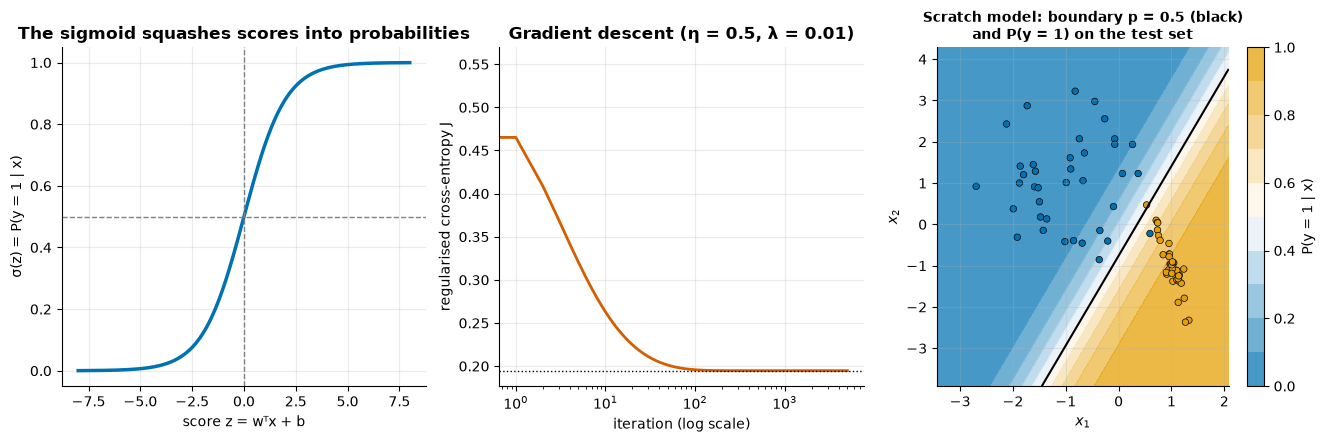

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
zz = np.linspace(-8, 8, 300)
axes[0].plot(zz, expit(zz), color=PALETTE[0], lw=2.5)
axes[0].axhline(0.5, color="grey", ls="--", lw=1)
axes[0].axvline(0, color="grey", ls="--", lw=1)
axes[0].set_xlabel("score z = wᵀx + b")
axes[0].set_ylabel("σ(z) = P(y = 1 | x)")
axes[0].set_title("The sigmoid squashes scores into probabilities")

axes[1].plot(scratch.loss_history_, color=PALETTE[3], lw=2)
axes[1].axhline(scratch.loss_history_[-1], color="black", ls=":", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("iteration (log scale)")
axes[1].set_ylabel("regularised cross-entropy J")
axes[1].set_title(f"Gradient descent (η = 0.5, λ = {lam})")

# decision surface of the *scratch* model, evaluated on a grid in original units
g1, g2 = np.meshgrid(np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 250),
                     np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 250))
P_grid = scratch.predict_proba(sc2.transform(np.c_[g1.ravel(), g2.ravel()]))[:, 1].reshape(g1.shape)
cf = axes[2].contourf(g1, g2, P_grid, levels=np.linspace(0, 1, 11), cmap=CMAP_BG, alpha=0.8)
axes[2].contour(g1, g2, P_grid, levels=[0.5], colors="black", linewidths=1.5)
axes[2].scatter(X2_te[:, 0], X2_te[:, 1], c=y2_te, cmap=CMAP_PTS, edgecolor="k", linewidth=0.5, s=22)
fig.colorbar(cf, ax=axes[2], label="P(y = 1 | x)")
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("$x_2$")
axes[2].set_title("Scratch model: boundary p = 0.5 (black)\nand P(y = 1) on the test set", fontsize=10)
savefig("logistic_regression_scratch")
plt.show()

The shading is $P(y=1\mid\mathbf x)$: it changes smoothly across the straight-line boundary, and its steepness
is set by $\lVert\mathbf w\rVert$. Stronger regularisation (larger $\lambda$, smaller $C$) shrinks
$\mathbf w$ and makes the model less confident.

### Multiclass: softmax regression

With $K$ classes, keep one weight vector per class and turn the $K$ scores into probabilities with the
**softmax**:

$$ P(y=k\mid\mathbf x) = \frac{\exp(\mathbf w_k^\top\mathbf x + b_k)}{\sum_{j=1}^K\exp(\mathbf w_j^\top\mathbf x + b_j)} .$$

The loss is the multiclass cross-entropy $-\frac1n\sum_i \log P(y_i\mid\mathbf x_i)$, and the gradient is again
"(predicted probability − one-hot target) × input". `LogisticRegression` uses this multinomial formulation
automatically when $K>2$. We classify the three **penguin** species from two bill measurements.

In [6]:
peng = load_penguins().dropna(subset=["bill_length_mm", "bill_depth_mm"])
Xp = peng[["bill_length_mm", "bill_depth_mm"]].to_numpy()
species = peng["species"].astype("category")
yp = species.cat.codes.to_numpy()
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(Xp, yp, test_size=0.25, random_state=RANDOM_STATE, stratify=yp)
softmax = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xp_tr, yp_tr)
print("coef_ shape (classes × features):", softmax[-1].coef_.shape)
print(f"test accuracy: {softmax.score(Xp_te, yp_te):.3f}")
example = np.array([[45.0, 17.0]])
pd.DataFrame(softmax.predict_proba(example).round(3), columns=species.cat.categories,
             index=["bill 45 mm × 17 mm"])

coef_ shape (classes × features): (3, 2)
test accuracy: 0.965


,Adelie,Chinstrap,Gentoo
bill 45 mm × 17 mm,0.192,0.566,0.242


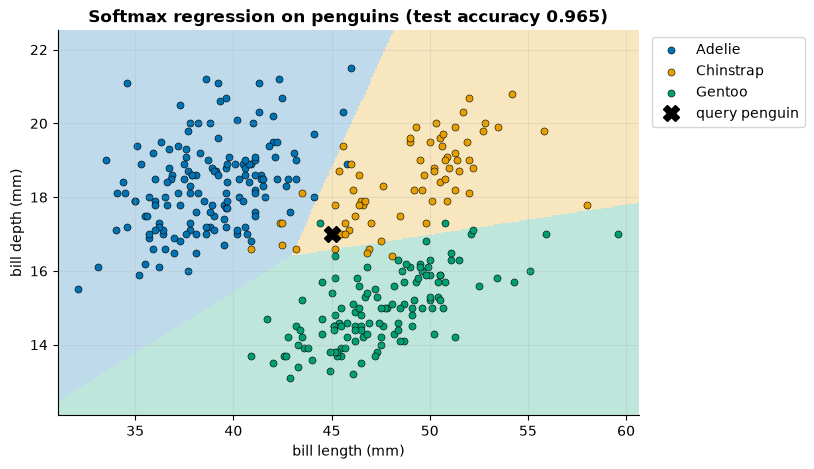

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
DecisionBoundaryDisplay.from_estimator(softmax, Xp, response_method="predict", alpha=0.25,
                                       multiclass_colors=PALETTE[:3],
                                       ax=ax, grid_resolution=300, plot_method="pcolormesh", eps=1)
for k, name in enumerate(species.cat.categories):
    m = yp == k
    ax.scatter(Xp[m, 0], Xp[m, 1], color=PALETTE[k], edgecolor="k", linewidth=0.4, s=26, label=name)
ax.plot(*example[0], "X", color="black", ms=12, label="query penguin")
ax.set_xlabel("bill length (mm)")
ax.set_ylabel("bill depth (mm)")
ax.set_title(f"Softmax regression on penguins (test accuracy {softmax.score(Xp_te, yp_te):.3f})")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
savefig("softmax_penguins")
plt.show()

The regions are separated by straight lines: each pairwise boundary is where two classes' linear scores tie.

## 2 · k-nearest neighbours

k-NN has no training phase at all: it stores the data. To classify $\mathbf x$, find the $k$ training points
closest to it (usually in Euclidean distance) and take a majority vote. It is **non-parametric** and makes no
assumption about the shape of the boundary.

### From scratch

All pairwise squared distances in one vectorised expression, using
$\lVert\mathbf a-\mathbf b\rVert^2 = \lVert\mathbf a\rVert^2 + \lVert\mathbf b\rVert^2 - 2\,\mathbf a^\top\mathbf b$:

In [8]:
def knn_predict(X_train, y_train, X_query, k=5):
    d2 = ((X_query**2).sum(1)[:, None] + (X_train**2).sum(1)[None, :] - 2 * X_query @ X_train.T)
    nearest = np.argsort(d2, axis=1)[:, :k]           # indices of the k closest training points
    votes = y_train[nearest]                           # their labels, shape (n_query, k)
    counts = np.apply_along_axis(np.bincount, 1, votes, minlength=y_train.max() + 1)
    return counts.argmax(axis=1)                       # majority vote (ties → smallest label)


Xm, ym = make_moons(n_samples=400, noise=0.3, random_state=RANDOM_STATE)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=RANDOM_STATE, stratify=ym)
for k in [1, 15, 51]:
    ours = knn_predict(Xm_tr, ym_tr, Xm_te, k)
    theirs = KNeighborsClassifier(k).fit(Xm_tr, ym_tr).predict(Xm_te)
    print(f"k = {k:>2}: identical predictions to sklearn: {np.array_equal(ours, theirs)}   "
          f"test accuracy = {np.mean(ours == ym_te):.3f}")

k =  1: identical predictions to sklearn: True   test accuracy = 0.850
k = 15: identical predictions to sklearn: True   test accuracy = 0.900
k = 51: identical predictions to sklearn: True   test accuracy = 0.933


### The effect of $k$

Small $k$ → flexible, jagged boundary that chases individual points (low bias, high variance). Large $k$ →
smooth boundary that may miss real structure (high bias, low variance). $k$ plays the role that polynomial
degree played in chapter 05, but in reverse.

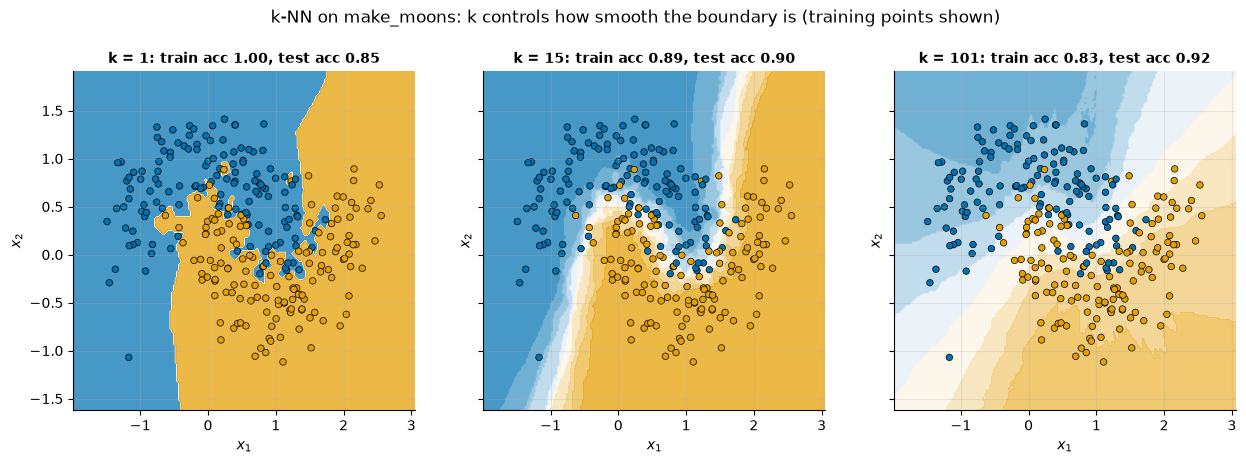

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, k in zip(axes, [1, 15, 101]):
    knn = KNeighborsClassifier(k).fit(Xm_tr, ym_tr)
    plot_boundary(ax, knn, Xm_tr, ym_tr, response="predict_proba", levels=np.linspace(0, 1, 11),
                  title=f"k = {k}: train acc {knn.score(Xm_tr, ym_tr):.2f}, test acc {knn.score(Xm_te, ym_te):.2f}")
fig.suptitle("k-NN on make_moons: k controls how smooth the boundary is (training points shown)", y=1.02)
savefig("knn_k_effect")
plt.show()

$k=1$ memorises the training set (train accuracy 1.00) and carves islands around noisy points. $k=101$ gives
an almost straight, blurry boundary that no longer follows the moons' curve — on this very noisy sample (and a
test set of only 120 points) it happens to score well, but its probabilities are washed out. The honest way to
pick $k$ is cross-validation over a grid (chapter 09).

### Scaling is not optional for k-NN

The **wine** dataset has 13 chemical measurements; `proline` ranges up to ~1 700 while `hue` lives around 1.
Unscaled, distance ≈ difference in proline.

In [10]:
wine = load_wine()
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"feature ranges: proline {np.ptp(wine.data[:, 12]):.0f}, hue {np.ptp(wine.data[:, 10]):.2f}")
for name, model in [("k-NN, raw features", KNeighborsClassifier(5)),
                    ("k-NN, standardised", make_pipeline(StandardScaler(), KNeighborsClassifier(5)))]:
    acc = cross_val_score(model, wine.data, wine.target, cv=cv5)
    print(f"{name:20s} 5-fold CV accuracy = {acc.mean():.3f} ± {acc.std():.3f}")

feature ranges: proline 1402, hue 1.23
k-NN, raw features   5-fold CV accuracy = 0.680 ± 0.043
k-NN, standardised   5-fold CV accuracy = 0.972 ± 0.018


### The curse of dimensionality

k-NN relies on "near" meaning "similar". In high dimensions this breaks down:

- **Distances concentrate.** For random points, the nearest and farthest neighbours end up almost equally
  far away, so "nearest" carries little information.
- **Neighbourhoods aren't local.** To capture a fraction $r$ of uniformly distributed data, a sub-cube needs
  edge length $r^{1/d}$: for $r=1\%$ that's 0.1 in 1-D but 0.63 in 10-D and 0.95 in 100-D.
- **Irrelevant features drown the signal**, because every noise dimension adds to the distance.

noise dims    0      2      5      10     20     50     100
k-NN        0.943  0.910  0.858  0.840  0.818  0.753  0.732
logistic    0.865  0.858  0.858  0.855  0.847  0.827  0.812
nearest/farthest ratio: {1: 0.001, 2: 0.014, 5: 0.125, 10: 0.261, 20: 0.414, 50: 0.596, 100: 0.694, 200: 0.774, 500: 0.853, 1000: 0.893}
edge length to capture 1% of the data: {1: 0.01, 2: 0.1, 10: 0.63, 100: 0.95}


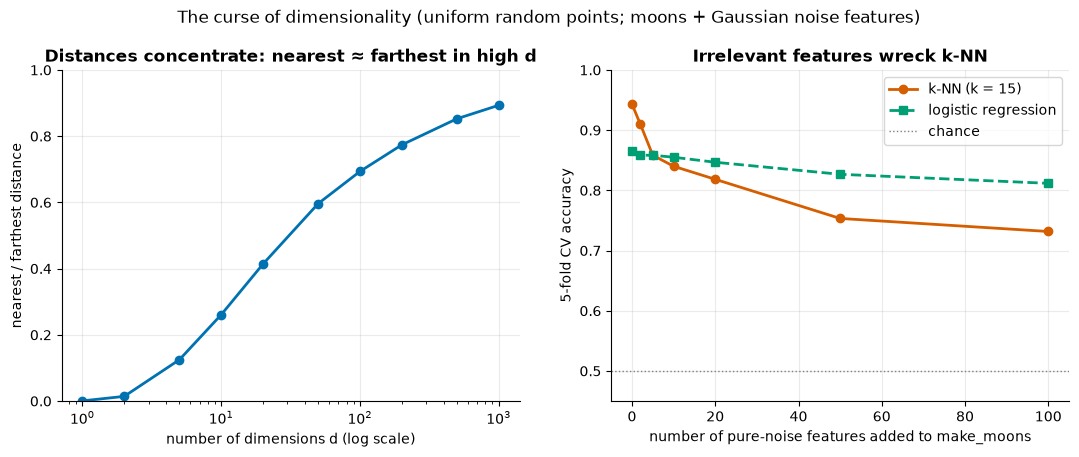

In [11]:
dims = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
ratio = []
for d in dims:
    P = rng.uniform(size=(1000, d))
    q = rng.uniform(size=(50, d))
    dist = np.sqrt(((q[:, None, :] - P[None, :, :]) ** 2).sum(-1))
    ratio.append(np.mean(dist.min(1) / dist.max(1)))

noise_dims = [0, 2, 5, 10, 20, 50, 100]
Xm_big, ym_big = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)
acc_knn, acc_lr = [], []
for nd in noise_dims:
    Xn = np.hstack([Xm_big, rng.normal(0, 1, (len(ym_big), nd))])
    acc_knn.append(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(15)), Xn, ym_big, cv=cv5).mean())
    acc_lr.append(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()), Xn, ym_big, cv=cv5).mean())
print(pd.DataFrame({"k-NN": acc_knn, "logistic": acc_lr}, index=pd.Index(noise_dims, name="noise dims")).T.round(3))
print("nearest/farthest ratio:", {d: round(float(r), 3) for d, r in zip(dims, ratio)})
print("edge length to capture 1% of the data:", {d: round(0.01 ** (1 / d), 2) for d in [1, 2, 10, 100]})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(dims, ratio, "o-", color=PALETTE[0], lw=2)
axes[0].set_xscale("log")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("number of dimensions d (log scale)")
axes[0].set_ylabel("nearest / farthest distance")
axes[0].set_title("Distances concentrate: nearest ≈ farthest in high d")
axes[1].plot(noise_dims, acc_knn, "o-", color=PALETTE[3], lw=2, label="k-NN (k = 15)")
axes[1].plot(noise_dims, acc_lr, "s--", color=PALETTE[2], lw=2, label="logistic regression")
axes[1].axhline(0.5, color="grey", ls=":", lw=1, label="chance")
axes[1].set_ylim(0.45, 1)
axes[1].set_xlabel("number of pure-noise features added to make_moons")
axes[1].set_ylabel("5-fold CV accuracy")
axes[1].set_title("Irrelevant features wreck k-NN")
axes[1].legend(frameon=True)
fig.suptitle("The curse of dimensionality (uniform random points; moons + Gaussian noise features)", y=1.02)
savefig("curse_of_dimensionality")
plt.show()

k-NN starts far ahead of the linear model on the curved moons data, but each noise feature dilutes the
distance until it is worse than logistic regression, which can simply learn a near-zero weight for useless
features. Feature selection or dimensionality reduction (chapter 10) is essential before k-NN in high
dimensions.

## 3 · Naive Bayes

A **generative** classifier: model how each class produces features, $P(\mathbf x\mid y)$, then invert with
Bayes' rule:

$$ P(y=k\mid\mathbf x) = \frac{P(y=k)\,P(\mathbf x\mid y=k)}{\sum_j P(y=j)\,P(\mathbf x\mid y=j)} .$$

The **naive** assumption: features are conditionally independent given the class, so the likelihood factorises,
$P(\mathbf x\mid y=k)=\prod_j P(x_j\mid y=k)$. **Gaussian NB** uses a 1-D normal for each feature and class:

$$ \log P(y=k\mid\mathbf x) = \log\pi_k
   - \sum_{j=1}^d\left[\tfrac12\log(2\pi\sigma_{kj}^2) + \frac{(x_j-\mu_{kj})^2}{2\sigma_{kj}^2}\right]
   - \log Z(\mathbf x). $$

Training is just counting and averaging — no optimisation. We work in log space (products of many small
densities underflow) and normalise with the **log-sum-exp** trick.

In [12]:
class GaussianNBScratch:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.class_prior_ = np.array([np.mean(y == c) for c in self.classes_])      # π_k
        self.theta_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])     # μ_kj
        eps = self.var_smoothing * X.var(axis=0).max()  # same stabiliser sklearn adds
        self.var_ = np.array([X[y == c].var(axis=0) for c in self.classes_]) + eps  # σ²_kj
        return self

    def _joint_log_likelihood(self, X):
        ll = -0.5 * (np.log(2 * np.pi * self.var_)[None, :, :]
                     + (X[:, None, :] - self.theta_[None, :, :]) ** 2 / self.var_[None, :, :]).sum(axis=2)
        return np.log(self.class_prior_) + ll          # shape (n, K)

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        return np.exp(jll - logsumexp(jll, axis=1, keepdims=True))

    def predict(self, X):
        return self.classes_[self._joint_log_likelihood(X).argmax(axis=1)]


num_feats = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
peng4 = load_penguins().dropna(subset=num_feats)
X4 = peng4[num_feats].to_numpy()
y4 = peng4["species"].astype("category").cat.codes.to_numpy()
X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4, y4, test_size=0.25, random_state=RANDOM_STATE, stratify=y4)

gnb_ours = GaussianNBScratch().fit(X4_tr, y4_tr)
gnb_sk = GaussianNB().fit(X4_tr, y4_tr)
print("priors match   :", np.allclose(gnb_ours.class_prior_, gnb_sk.class_prior_))
print("means match    :", np.allclose(gnb_ours.theta_, gnb_sk.theta_))
print("variances match:", np.allclose(gnb_ours.var_, gnb_sk.var_))
print("probas match   :", np.allclose(gnb_ours.predict_proba(X4_te), gnb_sk.predict_proba(X4_te)))
print(f"test accuracy  : {np.mean(gnb_ours.predict(X4_te) == y4_te):.3f}")
pd.DataFrame(gnb_ours.theta_, columns=num_feats, index=species.cat.categories).round(1)

priors match   : True
means match    : True
variances match: True
probas match   : True
test accuracy  : 0.988


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Adelie,38.9,18.4,190.2,3723.2
Chinstrap,49.1,18.6,196.6,3762.3
Gentoo,47.7,14.9,216.8,5068.8


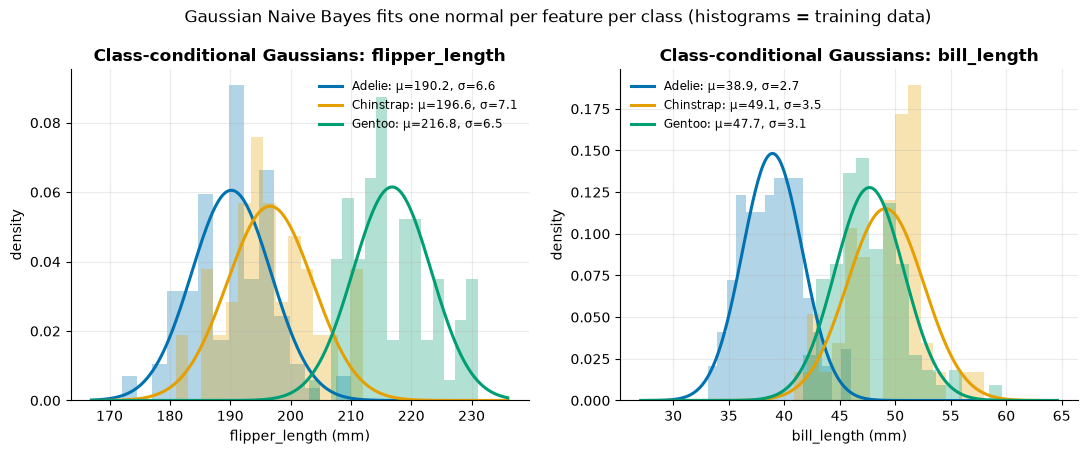

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, j, unit in zip(axes, [2, 0], ["mm", "mm"]):
    grid_j = np.linspace(X4[:, j].min() - 5, X4[:, j].max() + 5, 300)
    for k, name in enumerate(species.cat.categories):
        vals = X4_tr[y4_tr == k, j]
        ax.hist(vals, bins=15, density=True, alpha=0.3, color=PALETTE[k])
        mu, var = gnb_ours.theta_[k, j], gnb_ours.var_[k, j]
        dens = np.exp(-(grid_j - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)
        ax.plot(grid_j, dens, color=PALETTE[k], lw=2.2, label=f"{name}: μ={mu:.1f}, σ={np.sqrt(var):.1f}")
    ax.set_xlabel(f"{num_feats[j].replace('_mm', '')} ({unit})")
    ax.set_ylabel("density")
    ax.set_title(f"Class-conditional Gaussians: {num_feats[j].replace('_mm', '')}")
    ax.legend(fontsize=8.5, loc="upper right" if j == 2 else "upper left")
fig.suptitle("Gaussian Naive Bayes fits one normal per feature per class (histograms = training data)", y=1.02)
savefig("gaussian_nb_densities")
plt.show()

Flipper length separates Gentoo from the rest; bill length separates Adelie from Chinstrap. NB multiplies
the per-feature evidence as if it were independent. Features are in fact correlated (big penguins have long
flippers *and* heavy bodies), so NB's probabilities tend to be over-confident — but its *ranking* of classes
is often still good.

### Multinomial NB for text

For word counts, `MultinomialNB` models each class as a bag of words with per-class word probabilities
$\theta_{kw}$ (with Laplace smoothing $\alpha$: $\hat\theta_{kw} = \frac{N_{kw}+\alpha}{N_k+\alpha V}$).
It is fast, needs little data, and remains a strong baseline for spam filtering and topic classification.

In [14]:
docs = ["win cash prize now", "cheap meds win big", "claim your free prize", "limited offer win cash",
        "meeting moved to monday", "lunch on friday?", "project report attached", "see you at the meeting"]
labels = np.array([1, 1, 1, 1, 0, 0, 0, 0])  # 1 = spam
text_clf = make_pipeline(CountVectorizer(), MultinomialNB(alpha=1.0)).fit(docs, labels)
new = ["free cash prize", "report for the monday meeting"]
pd.DataFrame(text_clf.predict_proba(new).round(3), index=new, columns=["P(ham)", "P(spam)"])

,P(ham),P(spam)
free cash prize,0.056,0.944
report for the monday meeting,0.964,0.036


## 4 · Support vector machines

### Maximum margin

Many hyperplanes separate two separable classes. The SVM picks the one with the largest **margin** — the
distance to the closest training points. With labels $y_i\in\{-1,+1\}$ and the scaling convention
$y_i(\mathbf w^\top\mathbf x_i+b)\ge 1$, the margin width is $2/\lVert\mathbf w\rVert$, so:

$$ \min_{\mathbf w,b}\ \tfrac12\lVert\mathbf w\rVert^2 \quad\text{s.t.}\quad y_i(\mathbf w^\top\mathbf x_i+b)\ge1\ \ \forall i. $$

Only the points on the margin — the **support vectors** — determine the solution; move any other point
(without crossing the margin) and nothing changes.

### Soft margin and the hinge loss

Real data overlap, so we allow violations with a penalty $C$:

$$ \min_{\mathbf w,b}\ \tfrac12\lVert\mathbf w\rVert^2 + C\sum_i \max\big(0,\,1-y_i(\mathbf w^\top\mathbf x_i+b)\big). $$

The term $\max(0, 1-m)$ with margin $m=y f(\mathbf x)$ is the **hinge loss**: zero for points safely on the right
side, linear otherwise. Compare it with logistic regression's loss $\log(1+e^{-m})$ — the SVM is "regularised
empirical risk minimisation" with a different loss.

margin width 2/‖w‖ = 2.652,  support vectors: 3


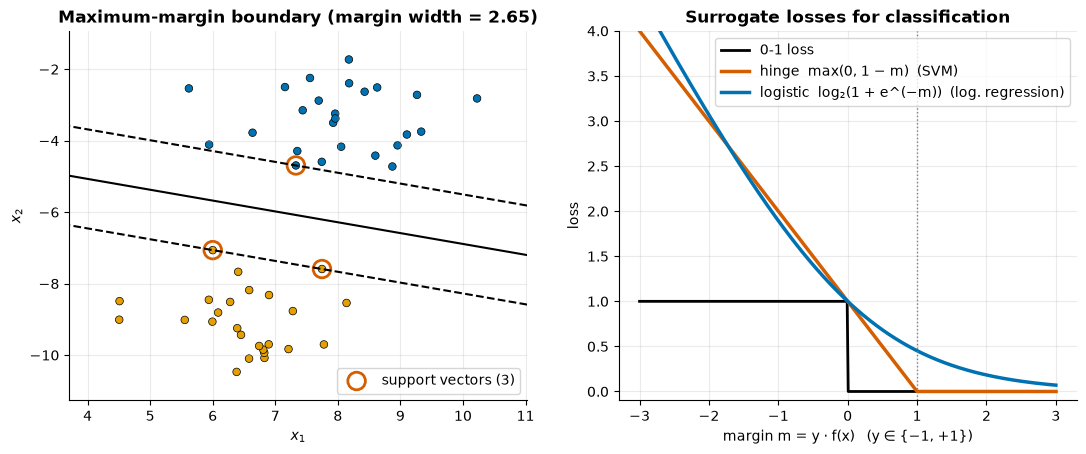

In [15]:
Xs, ys = make_blobs(n_samples=50, centers=2, cluster_std=0.9, random_state=6)
svm_hard = SVC(kernel="linear", C=1000).fit(Xs, ys)
w_svm = svm_hard.coef_.ravel()
print(f"margin width 2/‖w‖ = {2 / np.linalg.norm(w_svm):.3f},  support vectors: {len(svm_hard.support_)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap=CMAP_PTS, edgecolor="k", linewidth=0.5, s=30)
DecisionBoundaryDisplay.from_estimator(svm_hard, Xs, response_method="decision_function", plot_method="contour",
                                       levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"], ax=ax,
                                       eps=0.8)
ax.scatter(*svm_hard.support_vectors_.T, s=160, facecolors="none", edgecolors=PALETTE[3], linewidths=2,
           label=f"support vectors ({len(svm_hard.support_)})")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"Maximum-margin boundary (margin width = {2 / np.linalg.norm(w_svm):.2f})")
ax.legend(loc="lower right", frameon=True)

m = np.linspace(-3, 3, 400)
ax = axes[1]
ax.plot(m, (m <= 0).astype(float), color="black", lw=2, label="0-1 loss")
ax.plot(m, np.maximum(0, 1 - m), color=PALETTE[3], lw=2.5, label="hinge  max(0, 1 − m)  (SVM)")
ax.plot(m, np.logaddexp(0, -m) / np.log(2), color=PALETTE[0], lw=2.5,
        label="logistic  log₂(1 + e^(−m))  (log. regression)")
ax.axvline(1, color="grey", ls=":", lw=1)
ax.set_ylim(-0.1, 4)
ax.set_xlabel("margin m = y · f(x)   (y ∈ {−1, +1})")
ax.set_ylabel("loss")
ax.set_title("Surrogate losses for classification")
ax.legend(frameon=True)
savefig("svm_max_margin")
plt.show()

The hinge loss is exactly zero once $m\ge1$: points beyond the margin contribute nothing — that is why only
support vectors matter. The logistic loss is never exactly zero, so every point has some influence.

### The $C$ trade-off

$C$ is the price of a margin violation. Small $C$ → wide margin, many support vectors, more training errors
tolerated (more regularisation). Large $C$ → narrow margin that tries hard to classify every training point.
(Note $C$ is an *inverse* regularisation strength, as in `LogisticRegression`.)

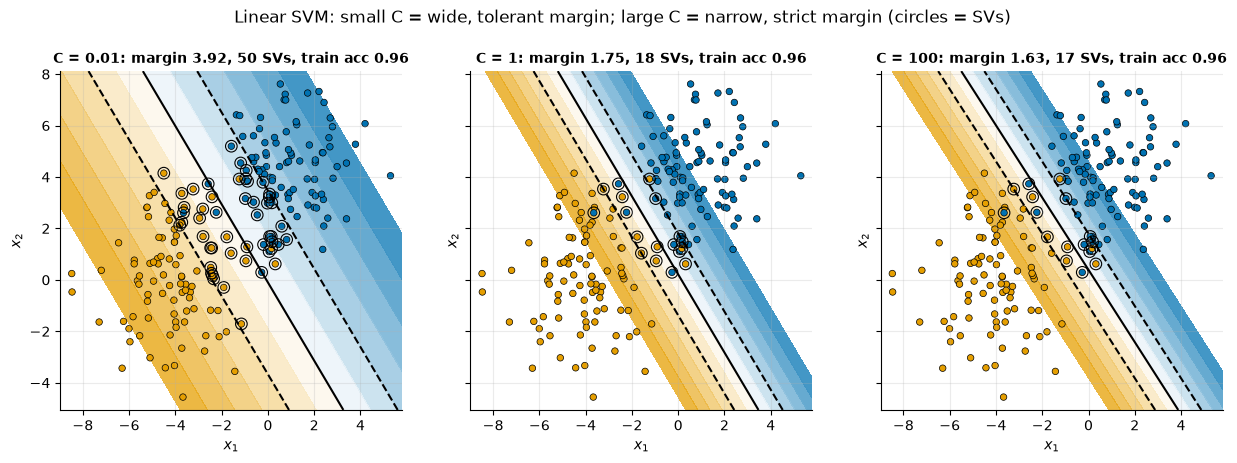

In [16]:
Xo, yo = make_blobs(n_samples=200, centers=2, cluster_std=1.6, random_state=3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, C in zip(axes, [0.01, 1, 100]):
    svm = SVC(kernel="linear", C=C).fit(Xo, yo)
    plot_boundary(ax, svm, Xo, yo, response="decision_function", levels=np.linspace(-3, 3, 13))
    DecisionBoundaryDisplay.from_estimator(svm, Xo, response_method="decision_function", plot_method="contour",
                                           levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"],
                                           ax=ax, eps=0.5)
    ax.scatter(*svm.support_vectors_.T, s=70, facecolors="none", edgecolors="black", linewidths=0.8)
    ax.set_title(f"C = {C}: margin {2 / np.linalg.norm(svm.coef_):.2f}, {len(svm.support_)} SVs, "
                 f"train acc {svm.score(Xo, yo):.2f}", fontsize=10)
fig.suptitle("Linear SVM: small C = wide, tolerant margin; large C = narrow, strict margin (circles = SVs)", y=1.02)
savefig("svm_C_effect")
plt.show()

### The kernel trick

A linear boundary can't separate concentric circles. But map each point to a higher-dimensional space,
e.g. $\phi(x_1,x_2) = (x_1, x_2, x_1^2+x_2^2)$, and a flat plane does the job. The SVM's dual problem and
prediction only ever use **inner products** $\langle\phi(\mathbf x_i),\phi(\mathbf x_j)\rangle$, so we can
replace them with a **kernel** $K(\mathbf x_i,\mathbf x_j)$ and never compute $\phi$ explicitly:

$$ f(\mathbf x) = \sum_{i\in\text{SV}} \alpha_i y_i K(\mathbf x_i,\mathbf x) + b,\qquad
   K_{\text{RBF}}(\mathbf x,\mathbf x') = \exp\!\big(-\gamma\lVert\mathbf x-\mathbf x'\rVert^2\big). $$

The RBF kernel corresponds to an *infinite-dimensional* feature map. Each support vector contributes a
Gaussian "bump" of width $\propto 1/\sqrt\gamma$ to the decision function.

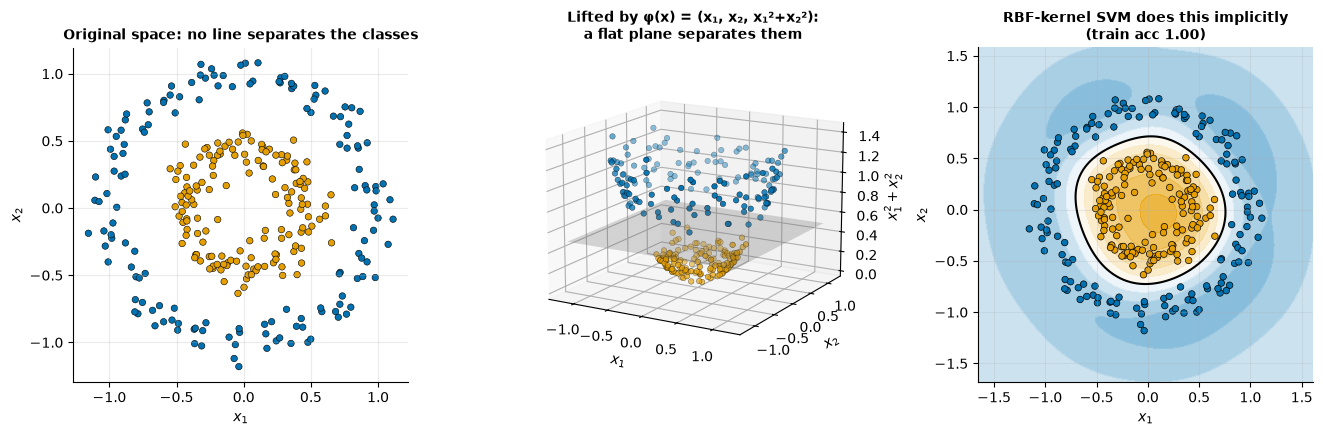

In [17]:
Xc, yc = make_circles(n_samples=300, noise=0.08, factor=0.45, random_state=RANDOM_STATE)
r2 = (Xc**2).sum(axis=1)
fig = plt.figure(figsize=(16, 4.8))
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap=CMAP_PTS, edgecolor="k", linewidth=0.4, s=22)
ax1.set_aspect("equal")
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.set_title("Original space: no line separates the classes", fontsize=10)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.scatter(Xc[:, 0], Xc[:, 1], r2, c=yc, cmap=CMAP_PTS, edgecolor="k", linewidth=0.3, s=16)
gx, gy = np.meshgrid(np.linspace(-1.2, 1.2, 10), np.linspace(-1.2, 1.2, 10))
ax2.plot_surface(gx, gy, np.full_like(gx, 0.5), alpha=0.25, color="grey")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_zlabel("$x_1^2 + x_2^2$", labelpad=2)
ax2.set_title("Lifted by φ(x) = (x₁, x₂, x₁²+x₂²):\na flat plane separates them", fontsize=10)
ax2.view_init(elev=15, azim=-60)

ax3 = fig.add_subplot(1, 3, 3)
svm_rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma=1, C=1)).fit(Xc, yc)
plot_boundary(ax3, svm_rbf, Xc, yc, response="decision_function", levels=np.linspace(-3, 3, 13))
DecisionBoundaryDisplay.from_estimator(svm_rbf, Xc, response_method="decision_function", plot_method="contour",
                                       levels=[0], colors="black", ax=ax3, eps=0.5)
ax3.set_aspect("equal")
ax3.set_title(f"RBF-kernel SVM does this implicitly\n(train acc {svm_rbf.score(Xc, yc):.2f})", fontsize=10)
fig.subplots_adjust(wspace=0.35)
savefig("kernel_trick")
plt.show()

### The effect of $\gamma$

$\gamma$ sets how far each support vector's influence reaches. Small $\gamma$ → broad bumps → smooth, almost
linear boundary (high bias). Large $\gamma$ → narrow bumps → the boundary wraps around individual points
(high variance). In practice tune $C$ and $\gamma$ **together** on a log grid (chapter 09).

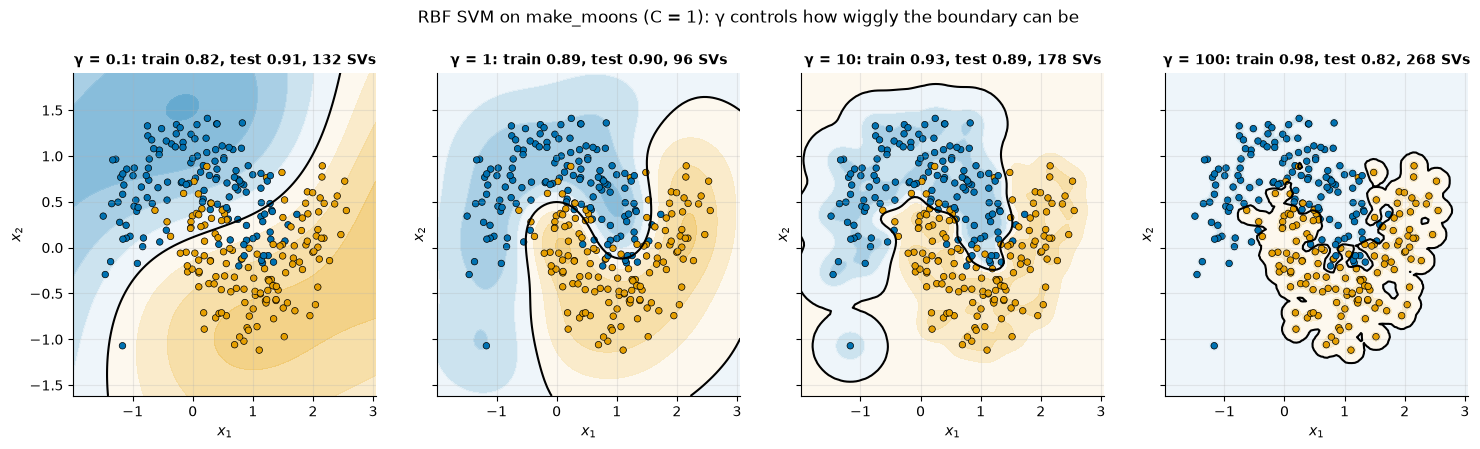

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, gamma in zip(axes, [0.1, 1, 10, 100]):
    svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma=gamma, C=1)).fit(Xm_tr, ym_tr)
    plot_boundary(ax, svm, Xm_tr, ym_tr, response="decision_function", levels=np.linspace(-3, 3, 13))
    DecisionBoundaryDisplay.from_estimator(svm, Xm_tr, response_method="decision_function",
                                           plot_method="contour", levels=[0], colors="black", ax=ax, eps=0.5)
    ax.set_title(f"γ = {gamma}: train {svm.score(Xm_tr, ym_tr):.2f}, test {svm.score(Xm_te, ym_te):.2f}, "
                 f"{len(svm[-1].support_)} SVs", fontsize=10)
fig.suptitle("RBF SVM on make_moons (C = 1): γ controls how wiggly the boundary can be", y=1.03)
savefig("svm_gamma_effect")
plt.show()

> **Practical notes.** SVMs need scaled features (the RBF kernel is a distance). `SVC` scales roughly as
> $O(n^2)$–$O(n^3)$, so for more than a few tens of thousands of rows use `LinearSVC` or
> `SGDClassifier(loss="hinge")`, or approximate kernels (`Nystroem`). `SVC` gives no probabilities unless
> `probability=True` (slow, via internal cross-validated Platt scaling).

## 5 · Head-to-head comparison

### Decision boundaries on three toy problems

In the spirit of scikit-learn's famous "classifier comparison" example: each row is a dataset, each column a
classifier; shading is the predicted probability or decision function, and the number in the corner is test
accuracy.

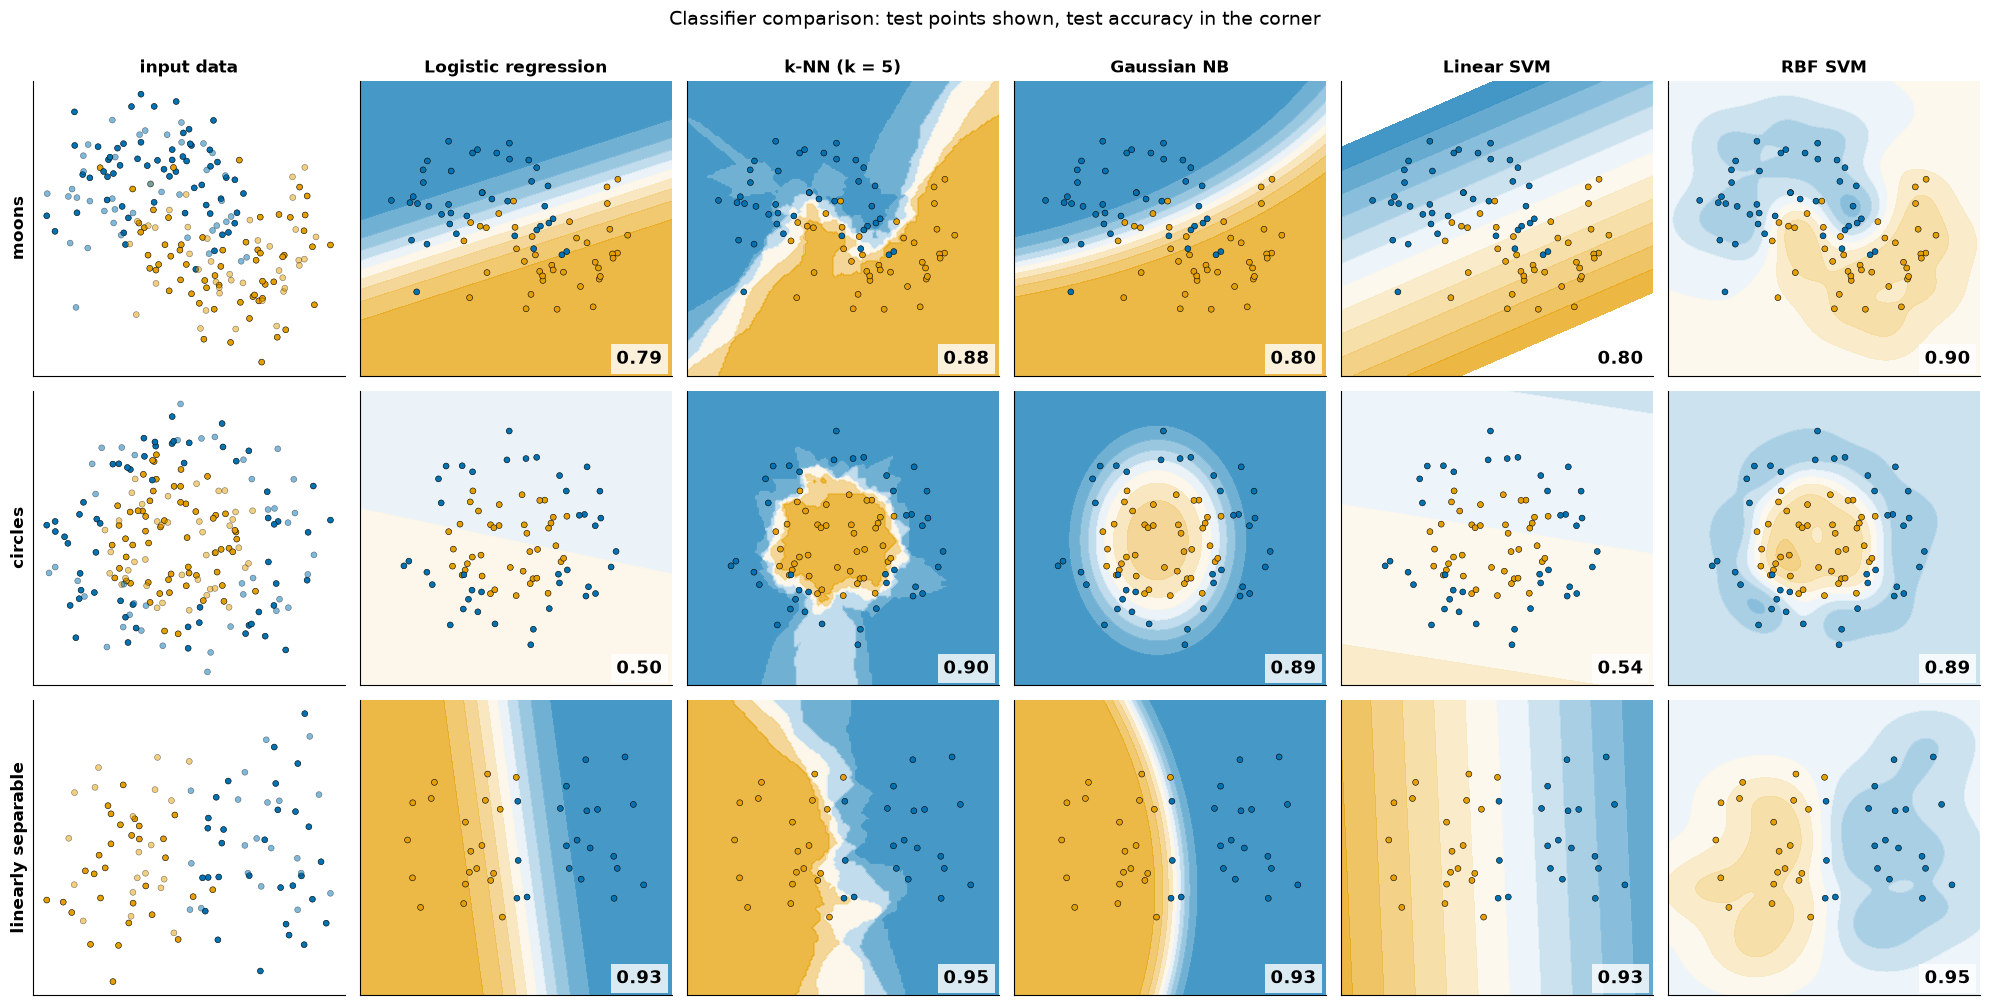

,moons,circles,linearly separable
Logistic regression,0.79,0.50,0.92
k-NN (k = 5),0.88,0.90,0.95
Gaussian NB,0.80,0.89,0.92
Linear SVM,0.80,0.54,0.92
RBF SVM,0.90,0.89,0.95


In [19]:
X_lin, y_lin = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=1,
                                   n_clusters_per_class=1)
X_lin += 2 * np.random.default_rng(2).uniform(size=X_lin.shape)
datasets = {
    "moons": make_moons(n_samples=200, noise=0.3, random_state=0),
    "circles": make_circles(n_samples=200, noise=0.2, factor=0.5, random_state=1),
    "linearly separable": (X_lin, y_lin),
}
classifiers = {
    "Logistic regression": LogisticRegression(),
    "k-NN (k = 5)": KNeighborsClassifier(5),
    "Gaussian NB": GaussianNB(),
    "Linear SVM": SVC(kernel="linear", C=0.1),
    "RBF SVM": SVC(kernel="rbf", gamma=2, C=1),
}
fig, axes = plt.subplots(len(datasets), len(classifiers) + 1, figsize=(20, 10))
comparison = {}
for i, (ds_name, (X, y)) in enumerate(datasets.items()):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
    ax = axes[i, 0]
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=CMAP_PTS, edgecolor="k", linewidth=0.4, s=18)
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap=CMAP_PTS, edgecolor="k", linewidth=0.4, s=18, alpha=0.5)
    ax.set_ylabel(ds_name, fontsize=12, fontweight="bold")
    if i == 0:
        ax.set_title("input data", fontsize=12)
    for j, (clf_name, clf) in enumerate(classifiers.items(), start=1):
        model = make_pipeline(StandardScaler(), clf).fit(X_tr, y_tr)
        score = model.score(X_te, y_te)
        comparison.setdefault(clf_name, {})[ds_name] = score
        ax = axes[i, j]
        resp = "predict_proba" if hasattr(model, "predict_proba") else "decision_function"
        levels = np.linspace(0, 1, 11) if resp == "predict_proba" else np.linspace(-3, 3, 13)
        DecisionBoundaryDisplay.from_estimator(model, X, response_method=resp, cmap=CMAP_BG, alpha=0.8, ax=ax,
                                               eps=0.5, grid_resolution=150, levels=levels)
        ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap=CMAP_PTS, edgecolor="k", linewidth=0.4, s=18)
        ax.text(0.97, 0.04, f"{score:.2f}", transform=ax.transAxes, ha="right", fontsize=13, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
        if i == 0:
            ax.set_title(clf_name, fontsize=12)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.grid(False)
for i in range(len(datasets)):
    axes[i, 0].set_ylabel(list(datasets)[i], fontsize=12, fontweight="bold")
fig.suptitle("Classifier comparison: test points shown, test accuracy in the corner", fontsize=14, y=1.0)
fig.tight_layout()
savefig("classifier_comparison")
plt.show()
pd.DataFrame(comparison).T.round(2)

- **Linear models** (logistic regression, linear SVM) can only draw straight lines — fine for the third
  dataset, useless for circles.
- **k-NN** and **RBF SVM** adapt to any shape.
- **Gaussian NB** draws quadratic (conic) boundaries, because each class is an axis-aligned Gaussian —
  excellent on circles, where the classes really are "narrow blob inside wide blob".

Test sets of 80 points are tiny, so treat differences of a few points as noise.

### A proper benchmark: breast cancer

569 tumours, 30 numeric features, binary target (malignant/benign). We use **repeated stratified 5-fold
cross-validation** (3 repeats = 15 fits per model), every model inside a pipeline so that scaling is learned
on training folds only, and report mean ± standard deviation. A `DummyClassifier` shows the baseline.

In [20]:
bc = load_breast_cancer()
Xbc, ybc = bc.data, bc.target
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "k-NN (k = 5), unscaled": KNeighborsClassifier(5),
    "k-NN (k = 5)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "Gaussian NB": make_pipeline(StandardScaler(), GaussianNB()),
    "Linear SVM (C = 1)": make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
    "RBF SVM (C = 1, γ = 'scale')": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1)),
}
rows = []
for name, model in models.items():
    res = cross_validate(model, Xbc, ybc, cv=rcv, scoring=["accuracy", "roc_auc", "f1"])
    rows.append({"model": name,
                 "accuracy": f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
                 "ROC AUC": f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
                 "F1": f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
                 "_acc": res["test_accuracy"].mean()})
bench = pd.DataFrame(rows).set_index("model")
bench.sort_values("_acc", ascending=False).drop(columns="_acc")

,accuracy,ROC AUC,F1
model,,,
Logistic regression,0.976 ± 0.013,0.995 ± 0.005,0.981 ± 0.010
"RBF SVM (C = 1, γ = 'scale')",0.976 ± 0.014,0.995 ± 0.005,0.981 ± 0.011
Linear SVM (C = 1),0.972 ± 0.018,0.994 ± 0.006,0.978 ± 0.014
k-NN (k = 5),0.967 ± 0.014,0.984 ± 0.010,0.974 ± 0.011
Gaussian NB,0.931 ± 0.018,0.988 ± 0.005,0.946 ± 0.014
"k-NN (k = 5), unscaled",0.930 ± 0.016,0.961 ± 0.018,0.945 ± 0.012
Dummy (most frequent),0.627 ± 0.004,0.500 ± 0.000,0.771 ± 0.003


With properly scaled features, every model is in the 93–98 % range and the differences between the top models
are within about one standard deviation — on this dataset the choice of classifier matters less than doing the
preprocessing and evaluation correctly. Unscaled k-NN is visibly worse. Chapter 08 goes deeper into metrics
and statistical comparison; chapter 09 tunes $C$, $\gamma$ and $k$ instead of using defaults.

## Key takeaways

- **Logistic regression**: linear log-odds, cross-entropy loss, gradient $X^\top(\mathbf p-\mathbf y)/n$;
  convex, calibrated-ish probabilities, interpretable coefficients. Softmax extends it to $K$ classes.
- **k-NN**: no training, flexible boundaries; $k$ trades variance for bias; needs scaling and suffers badly
  from irrelevant/high-dimensional features.
- **Naive Bayes**: generative, trains by counting; fast and data-efficient; independence assumption makes
  probabilities over-confident. Gaussian NB for continuous, Multinomial NB for counts/text.
- **SVM**: maximum margin; hinge loss means only support vectors matter; $C$ = violation penalty; kernels
  (RBF with $\gamma$) give non-linear boundaries without explicit features.
- Compare models with repeated, stratified cross-validation and pipelines — not a single split.

## Exercises

1. **Regularisation path.** Fit the from-scratch logistic regression with $\lambda\in\{0, 0.01, 0.1, 1\}$ and
   plot the boundary and $\lVert\mathbf w\rVert$. What happens with $\lambda=0$ on separable data?
   *Hint: without a penalty, $\lVert\mathbf w\rVert$ grows without bound when the data are separable.*
2. **Weighted k-NN.** Add a `weights="distance"` option to `knn_predict` (vote weight $1/d$) and compare with
   `KNeighborsClassifier(weights="distance")`. *Hint: use `np.add.at` to accumulate weighted votes.*
3. **When naive is wrong.** Create two classes with the same axis-aligned variances but opposite correlation
   (use `rng.multivariate_normal`). How does Gaussian NB do vs `QuadraticDiscriminantAnalysis`?
   *Hint: NB's per-class covariance is diagonal.*
4. **SVM by gradient descent.** Minimise $\tfrac{\lambda}{2}\lVert\mathbf w\rVert^2 + \frac1n\sum\max(0,1-y_i f(\mathbf x_i))$
   with sub-gradient descent and compare the boundary to `SVC(kernel="linear")`.
   *Hint: the sub-gradient of the hinge is $-y_i\mathbf x_i$ when $y_if(\mathbf x_i)<1$, else 0; $C = 1/(n\lambda)$.*
5. **Tune the RBF SVM.** Grid-search $C\in\{0.1,1,10,100\}$ and $\gamma\in\{0.001,0.01,0.1,1\}$ on breast
   cancer with nested CV. Does it beat the defaults? *Hint: wrap `GridSearchCV` in `cross_val_score`.*